### Подготовка окружения

In [1]:
from pathlib import Path
import sys

current_path = Path.cwd()
code_path = current_path.parent / 'code'
sys.path.append(str(code_path))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate
from thinkdsp import Wave, zero_pad
from thinkdsp import TriangleSignal, SquareSignal, SawtoothSignal, CubicSignal

### Упражнение 9.2

Сравним эффект `diff` (временная область) и `differentiate` (частотная область) на треугольном сигнале.

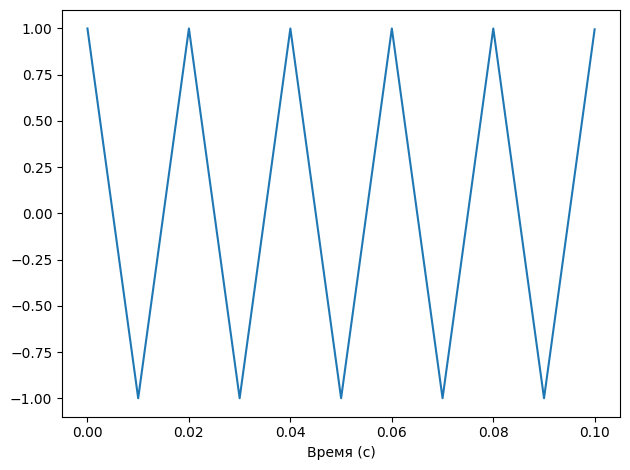

In [3]:
in_wave = TriangleSignal(freq=50).make_wave(duration=0.1, framerate=44100)
in_wave.plot()
decorate(xlabel='Время (с)')

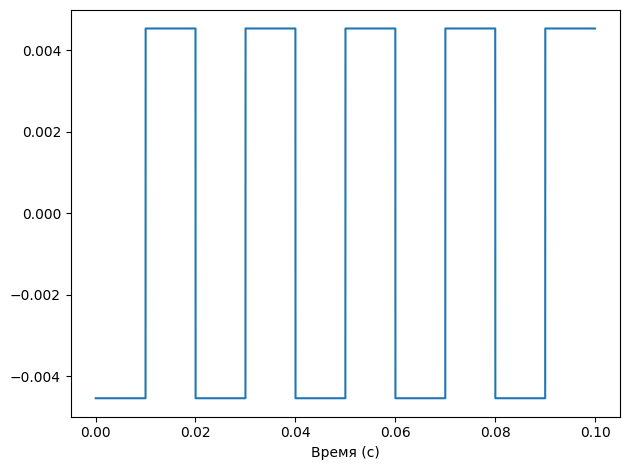

In [4]:
out_wave = in_wave.diff()
out_wave.plot()
decorate(xlabel='Время (с)')

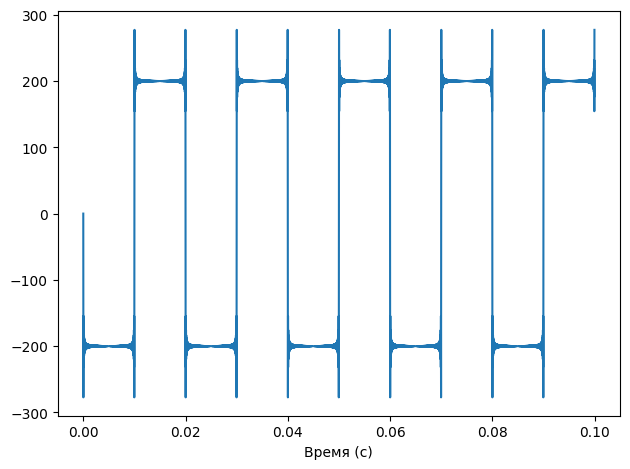

In [5]:
out_wave2 = in_wave.make_spectrum().differentiate().make_wave()
out_wave2.plot()
decorate(xlabel='Время (с)')

`diff` даёт чистый прямоугольный сигнал. `differentiate` даёт прямоугольный сигнал с звоном на разрывах, т.к. производная треугольного сигнала не определена в вершинах, и спектральный метод пытается представить разрыв конечным рядом Фурье.

### Упражнение 9.3

Сравним `cumsum` (временная область) и `integrate` (частотная область) на квадратном сигнале.

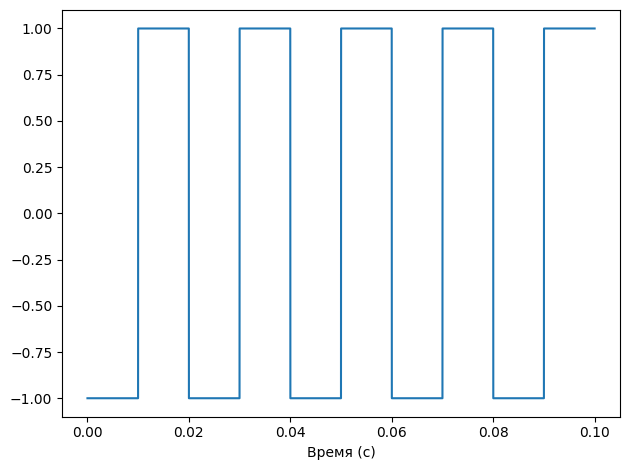

In [6]:
in_wave = SquareSignal(freq=50).make_wave(duration=0.1, framerate=44100)
in_wave.plot()
decorate(xlabel='Время (с)')

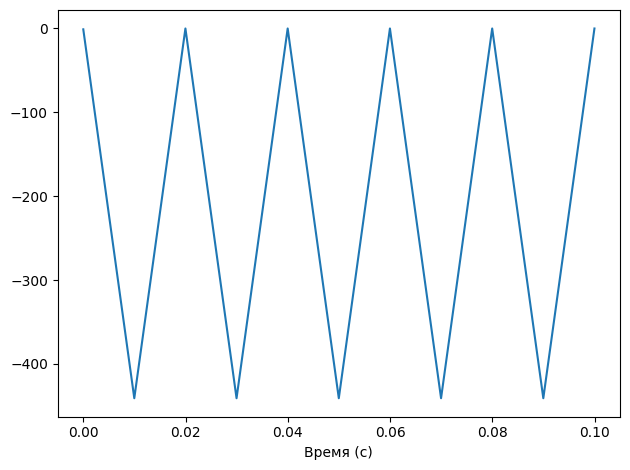

In [7]:
out_wave = in_wave.cumsum()
out_wave.plot()
decorate(xlabel='Время (с)')

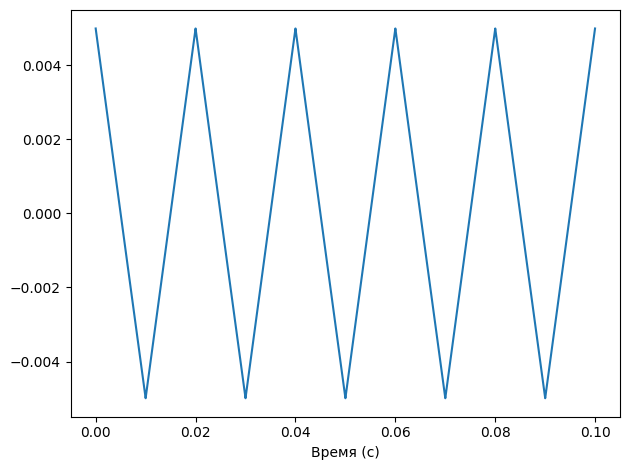

In [8]:
spectrum = in_wave.make_spectrum().integrate()
spectrum.hs[0] = 0
out_wave2 = spectrum.make_wave()
out_wave2.plot()
decorate(xlabel='Время (с)')

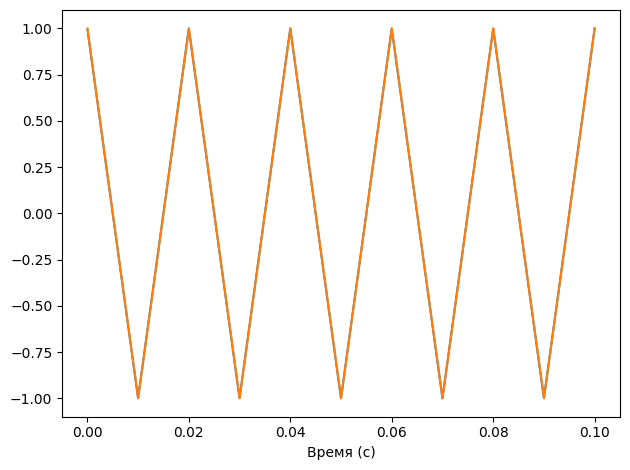

In [9]:
out_wave.unbias()
out_wave.normalize()
out_wave2.normalize()
out_wave.plot()
out_wave2.plot()
decorate(xlabel='Время (с)')

In [10]:
out_wave.max_diff(out_wave2)

np.float64(0.0045351473922902175)

Оба метода дают треугольный сигнал. После `unbias` и `normalize` формы практически совпадают (максимальная разница ~0.0045).

### Упражнение 9.4

Исследуем эффект двукратного интегрирования на пилообразном сигнале.

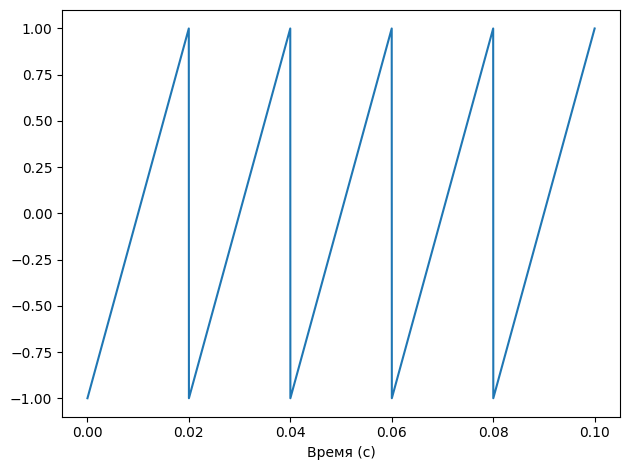

In [11]:
in_wave = SawtoothSignal(freq=50).make_wave(duration=0.1, framerate=44100)
in_wave.plot()
decorate(xlabel='Время (с)')

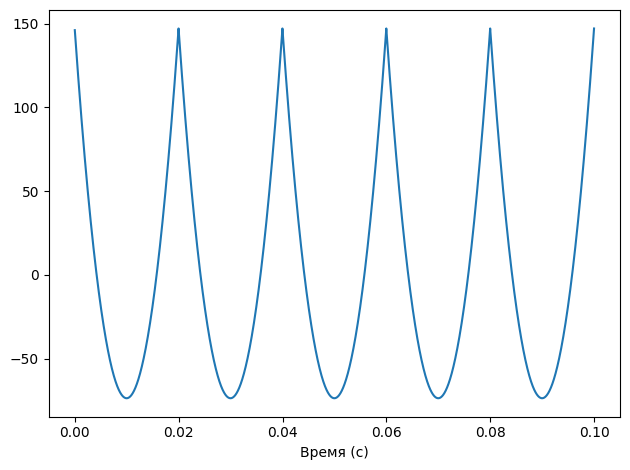

In [12]:
out_wave = in_wave.cumsum()
out_wave.unbias()
out_wave.plot()
decorate(xlabel='Время (с)')

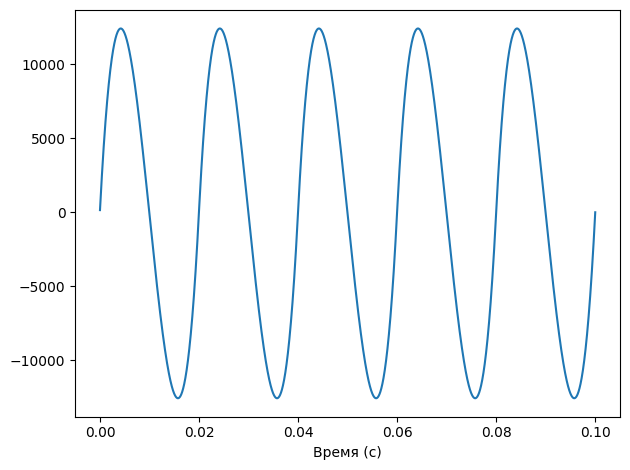

In [13]:
out_wave = out_wave.cumsum()
out_wave.plot()
decorate(xlabel='Время (с)')

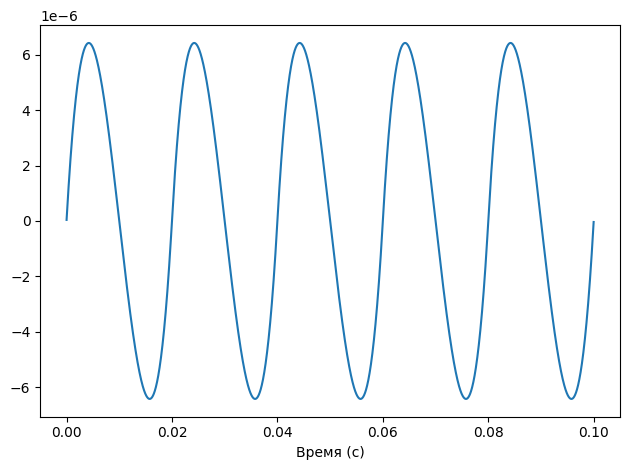

In [14]:
spectrum = in_wave.make_spectrum().integrate().integrate()
spectrum.hs[0] = 0
out_wave2 = spectrum.make_wave()
out_wave2.plot()
decorate(xlabel='Время (с)')

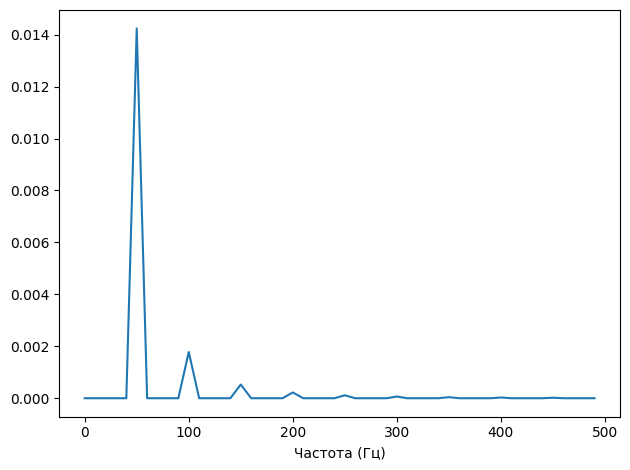

In [15]:
out_wave2.make_spectrum().plot(high=500)
decorate(xlabel='Частота (Гц)')

Первое интегрирование пилы даёт параболу, второе — кубическую кривую. После двукратного спектрального интегрирования остаётся практически только фундаментальная частота — интегрирование действует как фильтр нижних частот ($1/\omega^2$). Форма волны напоминает синусоиду.

### Упражнение 9.5

Сравним вторую разность (`diff` дважды) и вторую производную (`differentiate` дважды) на кубическом сигнале. Построим соответствующие фильтры.

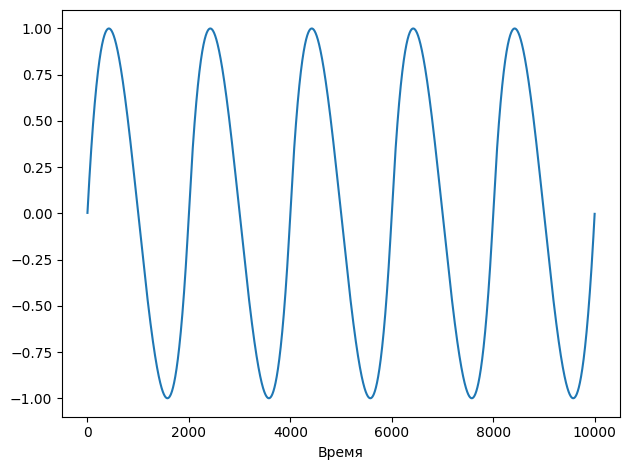

In [16]:
in_wave = CubicSignal(freq=0.0005).make_wave(duration=10000, framerate=1)
in_wave.plot()
decorate(xlabel='Время')

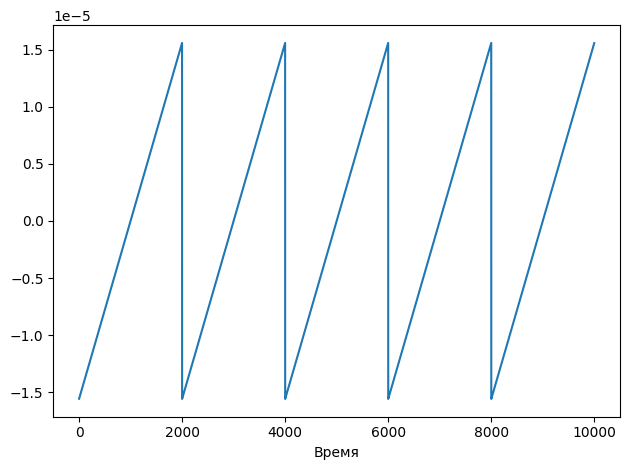

In [17]:
out_wave = in_wave.diff().diff()
out_wave.plot()
decorate(xlabel='Время')

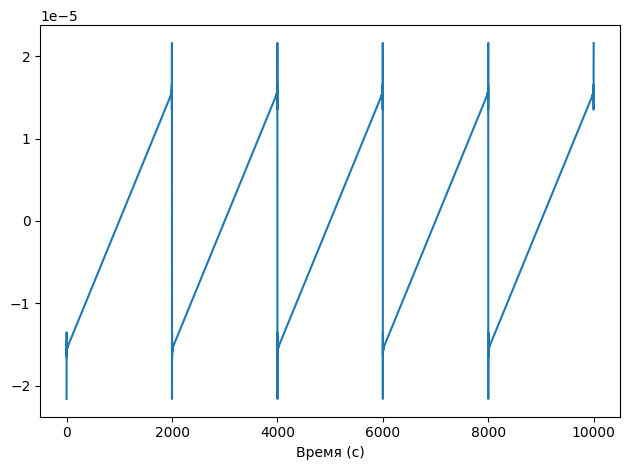

In [18]:
spectrum = in_wave.make_spectrum().differentiate().differentiate()
out_wave2 = spectrum.make_wave()
out_wave2.plot()
decorate(xlabel='Время (с)')

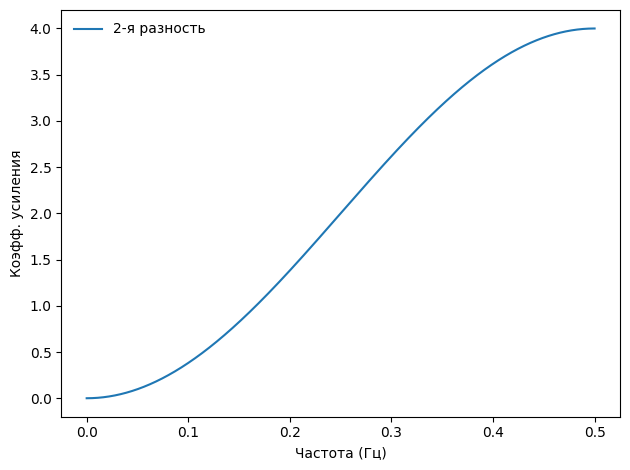

In [19]:
PI2 = 2 * np.pi

diff_window = np.array([-1.0, 2.0, -1.0])
padded = zero_pad(diff_window, len(in_wave))
diff_wave = Wave(padded, framerate=in_wave.framerate)
diff_filter = diff_wave.make_spectrum()
diff_filter.plot(label='2-я разность')
decorate(xlabel='Частота (Гц)', ylabel='Коэфф. усиления')

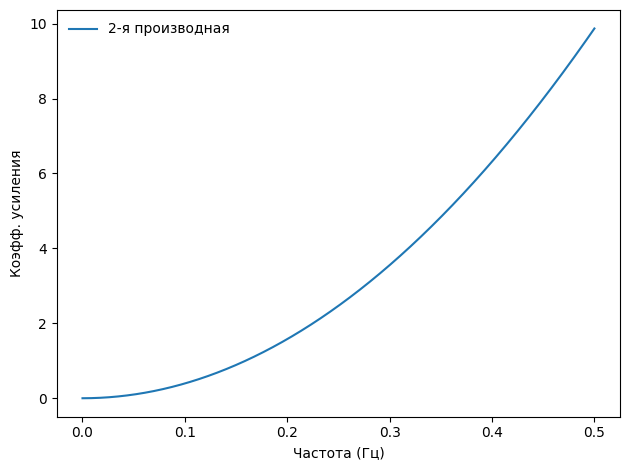

In [20]:
deriv_filter = in_wave.make_spectrum()
deriv_filter.hs = (PI2 * 1j * deriv_filter.fs) ** 2
deriv_filter.plot(label='2-я производная')
decorate(xlabel='Частота (Гц)', ylabel='Коэфф. усиления')

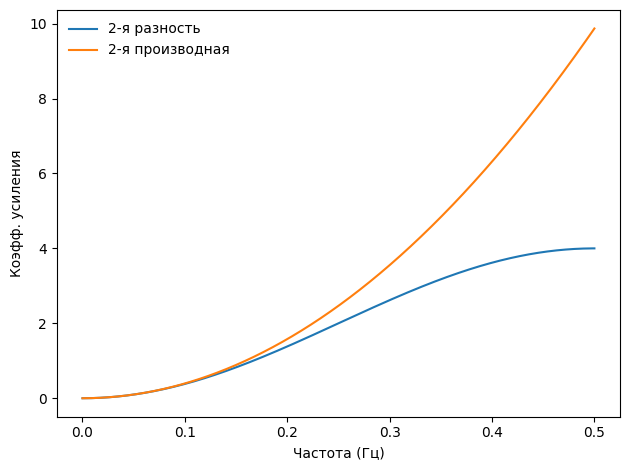

In [21]:
diff_filter.plot(label='2-я разность')
deriv_filter.plot(label='2-я производная')
decorate(xlabel='Частота (Гц)', ylabel='Коэфф. усиления')

- Вторая разность кубического сигнала даёт пилообразную волну (без шума).
- Вторая производная через спектр даёт ту же форму, но с звоном на разрывах (явления Гиббса).
- Фильтр второй разности (окно `[-1, 2, -1]`) — это high-pass фильтр, хорошо аппроксимирующий параболический фильтр второй производной только на низких частотах. На высоких частотах расходится.